<a href="https://colab.research.google.com/github/Shahriahusen/Data_Analysist_Ai-_agent/blob/main/Upload_linkdin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving netflix_titles.csv to netflix_titles (3).csv
Success! Uploaded netflix_titles (3).csv
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 

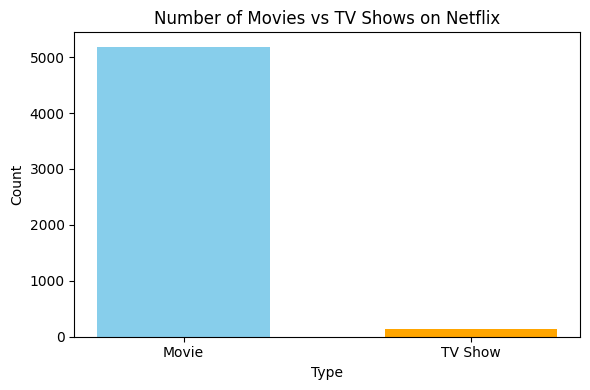

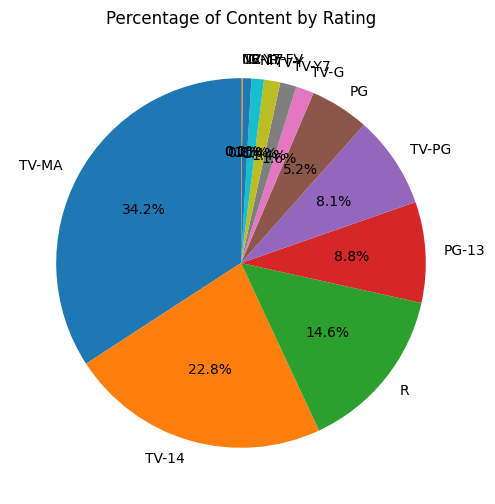

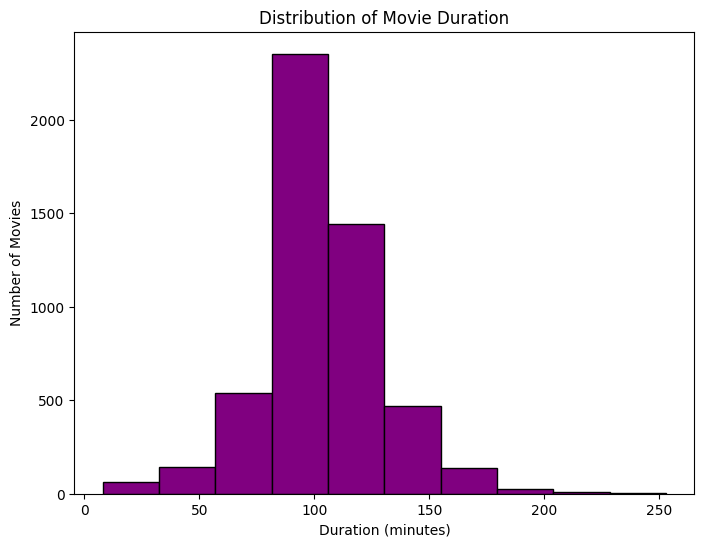

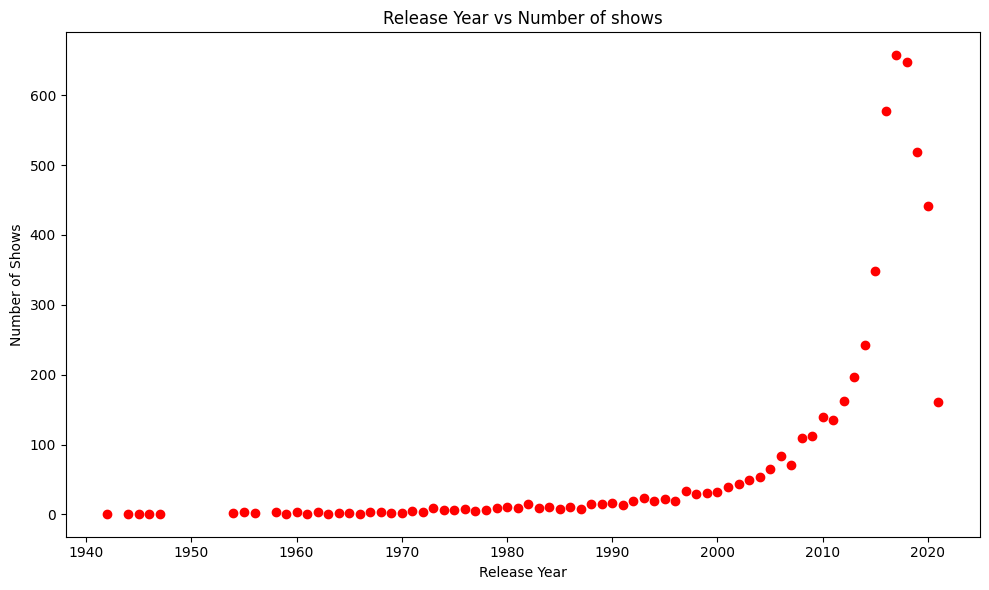

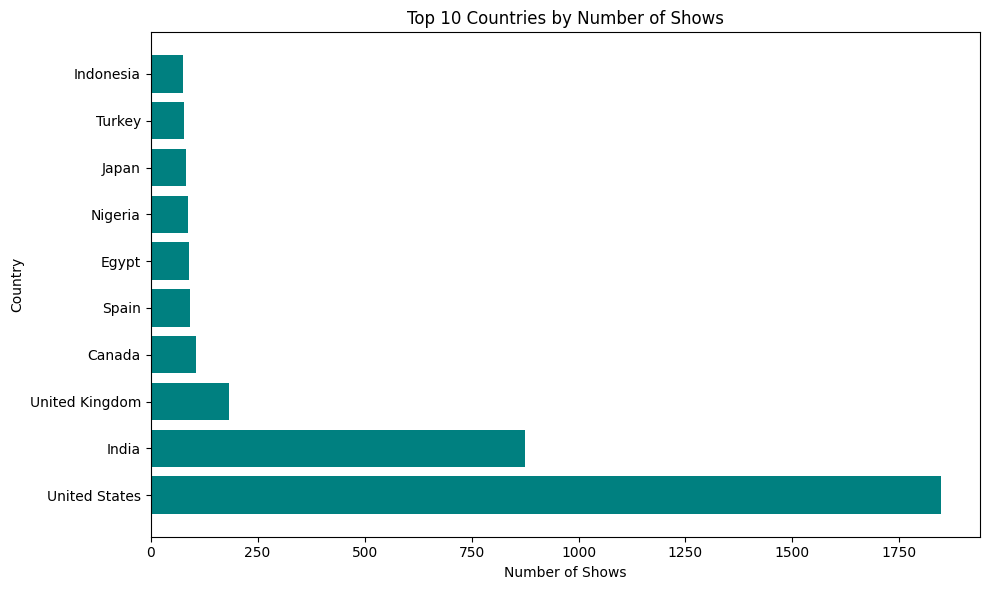

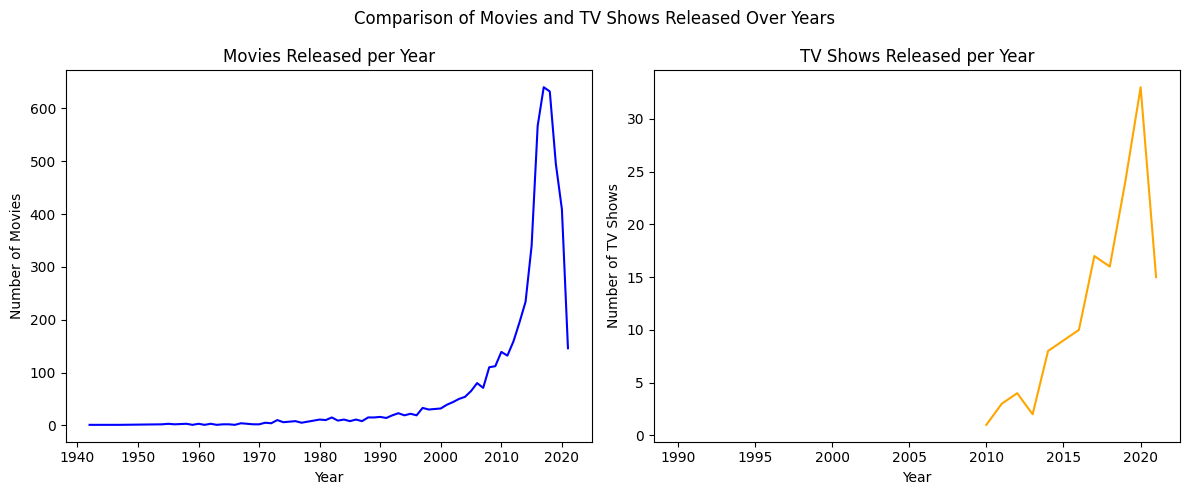

In [4]:
import matplotlib.pyplot as plt
from google.colab import files
import pandas as pd
import io

# Upload file
uploaded = files.upload()

# Read file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Confirm upload
print(f"Success! Uploaded {file_name}")
print(df.head())

# Check missing values (optional)
print(df.isnull().sum())

# Drop missing values (optional)
df = df.dropna()


type_counts = df['type'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'orange'],width=0.6)
plt.title('Number of Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


rating_counts = df['rating'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title('Percentage of Content by Rating')
plt.show()


movie_df = df[df['type'] == 'Movie'].copy()

# Clean duration column
movie_df['duration'] = movie_df['duration'].str.replace('min', '').str.strip()
movie_df['duration'] = movie_df['duration'].astype(int)

# Create histogram
plt.figure(figsize=(8, 6))
plt.hist(movie_df['duration'], color='purple',edgecolor='black')

plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.show()

release_counts=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index,release_counts.values,color='red')
plt.title('Release Year vs Number of shows')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.tight_layout()
plt.show()


# Horizontal Bar chart
country_counts = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(country_counts.index, country_counts.values, color='teal')

plt.title('Top 10 Countries by Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Country')

plt.tight_layout()
plt.show()


content_by_year = df.groupby(['release_year', 'type']).size().unstack()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].plot(content_by_year.index, content_by_year['Movie'], color='blue')
ax[0].set_title('Movies Released per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')


ax[1].plot(content_by_year.index, content_by_year['TV Show'], color='orange')
ax[1].set_title('TV Shows Released per Year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of TV Shows')

# Overall title
fig.suptitle('Comparison of Movies and TV Shows Released Over Years')

plt.tight_layout()
plt.show()

